# Esplorazione del benchmark KANDY

Analisi esplorativa del dataset KANDY come base per gli esperimenti di Explainable AI.

Questo notebook analizza:

- struttura del dataset;
- distribuzione delle task;
- bilanciamento delle etichette;
- esempi di immagini;
- annotazioni simboliche;
- concetti visivi;
- struttura delle task e delle relative regole.

L’analisi prepara il dataset per le successive componenti del progetto:

- baseline CNN;
- spiegazioni con SHAP;
- Concept Bottleneck Models (CBM);
- valutazione della fedeltà alle regole;
- analisi degli shortcut.

## 1. Ambiente

In [1]:
import sys

print("Python executable:", sys.executable)
print("Python version:", sys.version)


Python executable: /home/cosimo/Downloads/kandy-xai/.venv/bin/python
Python version: 3.11.9 (main, Aug  7 2026, 13:00:06) [GCC 16.1.1 20260728]


## 2. Import e percorsi

In [2]:
from pathlib import Path
from collections import Counter
import ast

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data" / "samples" / "sets"

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

TRAIN_CSV = TRAIN_DIR / "annotations.csv"
VAL_CSV = VAL_DIR / "annotations.csv"
TEST_CSV = TEST_DIR / "annotations.csv"

print("Project root:", PROJECT_ROOT)
print("Train directory:", TRAIN_DIR)
print("Validation directory:", VAL_DIR)
print("Test directory:", TEST_DIR)


Project root: /home/cosimo/Downloads/kandy-xai
Train directory: /home/cosimo/Downloads/kandy-xai/data/samples/sets/train
Validation directory: /home/cosimo/Downloads/kandy-xai/data/samples/sets/val
Test directory: /home/cosimo/Downloads/kandy-xai/data/samples/sets/test


## 3. Caricamento delle annotazioni

In [3]:
df_train = pd.read_csv(TRAIN_CSV)
df_val = pd.read_csv(VAL_CSV)
df_test = pd.read_csv(TEST_CSV)

print("Train samples:", len(df_train))
print("Validation samples:", len(df_val))
print("Test samples:", len(df_test))

df_train.head()


Train samples: 1000
Validation samples: 500
Test samples: 500


,filename,task_id,label,supervised,symbol
0,0/0000.png,0,1,1,"{'quadrant_lr': [{'shape': 'triangle', 'color'..."
1,0/0001.png,0,0,1,"{'quadrant_lr': [{'shape': 'circle', 'color': ..."
2,0/0002.png,0,0,1,"{'quadrant_ur': [{'shape': 'circle', 'color': ..."
3,0/0003.png,0,1,1,"{'quadrant_ll': [{'shape': 'triangle', 'color'..."
4,0/0004.png,0,0,1,"{'quadrant_ul': [{'shape': 'circle', 'color': ..."


In [4]:
df_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   filename    1000 non-null   str  
 1   task_id     1000 non-null   int64
 2   label       1000 non-null   int64
 3   supervised  1000 non-null   int64
 4   symbol      1000 non-null   str  
dtypes: int64(3), str(2)
memory usage: 39.2 KB


### Campi delle annotazioni

- `filename`: percorso relativo dell’immagine;
- `task_id`: identificatore della task KANDY;
- `label`: etichetta binaria;
- `supervised`: indicatore di supervisione;
- `symbol`: descrizione simbolica della scena.

## 4. Statistiche del dataset

In [5]:
n_tasks = df_train["task_id"].nunique()

print("Number of tasks:", n_tasks)
print("Training samples:", len(df_train))
print("\nSamples per task:")
print(df_train["task_id"].value_counts().sort_index())


Number of tasks: 20
Training samples: 1000

Samples per task:
task_id
0     50
1     50
2     50
3     50
4     50
5     50
6     50
7     50
8     50
9     50
10    50
11    50
12    50
13    50
14    50
15    50
16    50
17    50
18    50
19    50
Name: count, dtype: int64


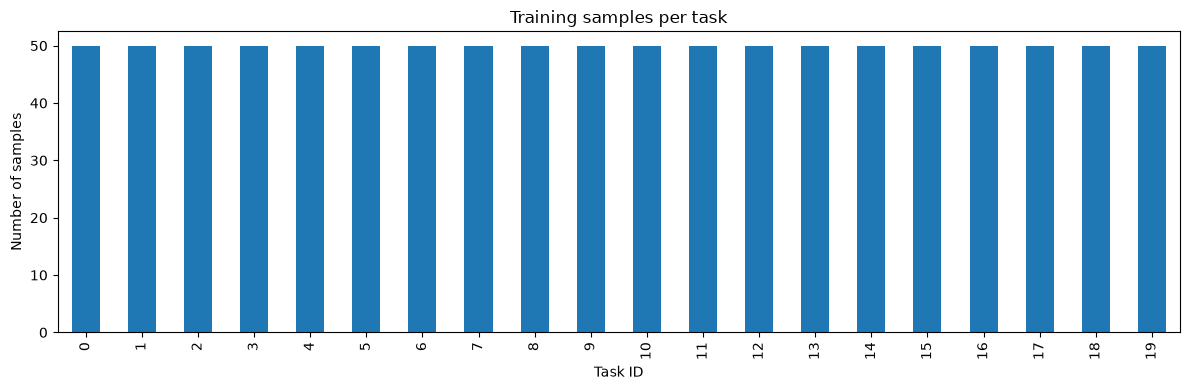

In [6]:
task_distribution = df_train["task_id"].value_counts().sort_index()

ax = task_distribution.plot(
    kind="bar",
    figsize=(12, 4),
    title="Training samples per task"
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Number of samples")
plt.tight_layout()
plt.show()


## 5. Distribuzione delle etichette

In [7]:
label_distribution = df_train["label"].value_counts().sort_index()
print(label_distribution)


label
0    594
1    406
Name: count, dtype: int64


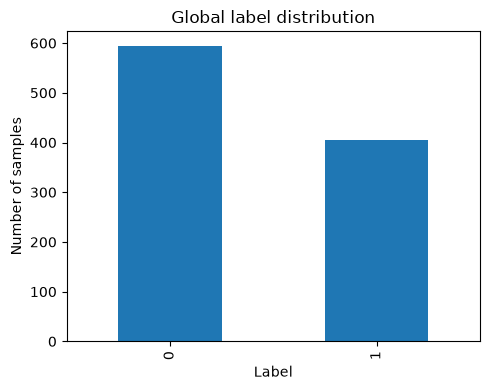

In [8]:
ax = label_distribution.plot(
    kind="bar",
    figsize=(5, 4),
    title="Global label distribution"
)
ax.set_xlabel("Label")
ax.set_ylabel("Number of samples")
plt.tight_layout()
plt.show()


In [9]:
majority_baseline = df_train["label"].value_counts(normalize=True).max()
print(f"Majority baseline accuracy: {majority_baseline:.2%}")


Majority baseline accuracy: 59.40%


Il baseline ottenuto scegliendo sempre la classe maggioritaria costituisce un riferimento per la CNN. Un modello utile dovrebbe superarlo in modo significativo prima di procedere con l’analisi delle sue spiegazioni.

## 6. Distribuzione delle etichette per task

In [10]:
task_labels = (
    df_train.groupby("task_id")["label"]
    .agg(total="count", positives="sum")
)

task_labels["negatives"] = task_labels["total"] - task_labels["positives"]
task_labels["positive_ratio"] = task_labels["positives"] / task_labels["total"]

task_labels


,total,positives,negatives,positive_ratio
task_id,,,,
0,50,20,30,0.40
1,50,20,30,0.40
2,50,28,22,0.56
3,50,13,37,0.26
4,50,13,37,0.26
5,50,11,39,0.22
6,50,11,39,0.22
7,50,14,36,0.28
8,50,15,35,0.30


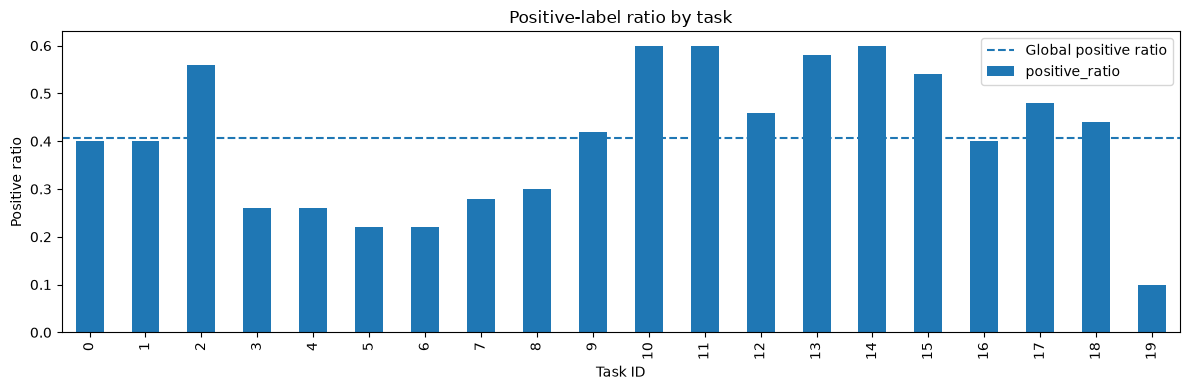

In [11]:
ax = task_labels["positive_ratio"].plot(
    kind="bar",
    figsize=(12, 4),
    title="Positive-label ratio by task"
)
ax.set_xlabel("Task ID")
ax.set_ylabel("Positive ratio")
plt.axhline(df_train["label"].mean(), linestyle="--", label="Global positive ratio")
plt.legend()
plt.tight_layout()
plt.show()


Le task presentano livelli diversi di bilanciamento tra le classi. La task 19 (`traffic light`) è particolarmente sbilanciata nel training set; per questo, nelle valutazioni successive non è opportuno affidarsi alla sola accuracy.

## 7. Parsing delle annotazioni simboliche

In [12]:
df_train["symbol_parsed"] = df_train["symbol"].apply(ast.literal_eval)

df_train[["filename", "task_id", "label", "symbol", "symbol_parsed"]].head()


,filename,task_id,label,symbol,symbol_parsed
0,0/0000.png,0,1,"{'quadrant_lr': [{'shape': 'triangle', 'color'...","{'quadrant_lr': [{'shape': 'triangle', 'color'..."
1,0/0001.png,0,0,"{'quadrant_lr': [{'shape': 'circle', 'color': ...","{'quadrant_lr': [{'shape': 'circle', 'color': ..."
2,0/0002.png,0,0,"{'quadrant_ur': [{'shape': 'circle', 'color': ...","{'quadrant_ur': [{'shape': 'circle', 'color': ..."
3,0/0003.png,0,1,"{'quadrant_ll': [{'shape': 'triangle', 'color'...","{'quadrant_ll': [{'shape': 'triangle', 'color'..."
4,0/0004.png,0,0,"{'quadrant_ul': [{'shape': 'circle', 'color': ...","{'quadrant_ul': [{'shape': 'circle', 'color': ..."


Il campo `symbol` contiene una rappresentazione della scena in formato simile a un dizionario Python. Queste annotazioni sono particolarmente importanti per i successivi esperimenti con Concept Bottleneck Model.

## 8. Analisi dei concetti simbolici

In [13]:
def iter_objects(symbol):
    for position, objects in symbol.items():
        for obj in objects:
            yield position, obj

structure_counter = Counter()

for symbol in df_train["symbol_parsed"]:
    for position, objects in symbol.items():
        for obj in objects:
            structure_counter[tuple(sorted(obj.keys()))] += 1

print("Different object structures found:")
for structure, count in structure_counter.items():
    print(f"{count:4d} -> {structure}")


Different object structures found:
1368 -> ('color', 'shape', 'size')
   6 -> ('grid',)
 156 -> ('stack',)
   9 -> ('stack_reduce_bb',)
   4 -> ('diag_ul_lr',)
   9 -> ('diag_ll_ur',)
   7 -> ('side_by_side_reduce_bb',)
 109 -> ('side_by_side',)


In [14]:
shape_counter = Counter()
color_counter = Counter()
size_counter = Counter()
position_counter = Counter()

for symbol in df_train["symbol_parsed"]:
    for position, obj in iter_objects(symbol):
        position_counter[position] += 1
        if "shape" in obj:
            shape_counter[obj["shape"]] += 1
        if "color" in obj:
            color_counter[obj["color"]] += 1
        if "size" in obj:
            size_counter[obj["size"]] += 1

print("Shape counts:", dict(shape_counter))
print("Color counts:", dict(color_counter))
print("Size counts:", dict(size_counter))
print("Position counts:", dict(position_counter))


Shape counts: {'triangle': 523, 'circle': 428, 'square': 417}
Color counts: {'blue': 236, 'cyan': 195, 'magenta': 193, 'yellow': 209, 'green': 207, 'red': 328}
Size counts: {'large': 676, 'small': 692}
Position counts: {'quadrant_lr': 130, 'quadrant_ur': 157, 'quadrant_ll': 150, 'quadrant_ul': 164, 'in': 149, 'side_by_side': 918}


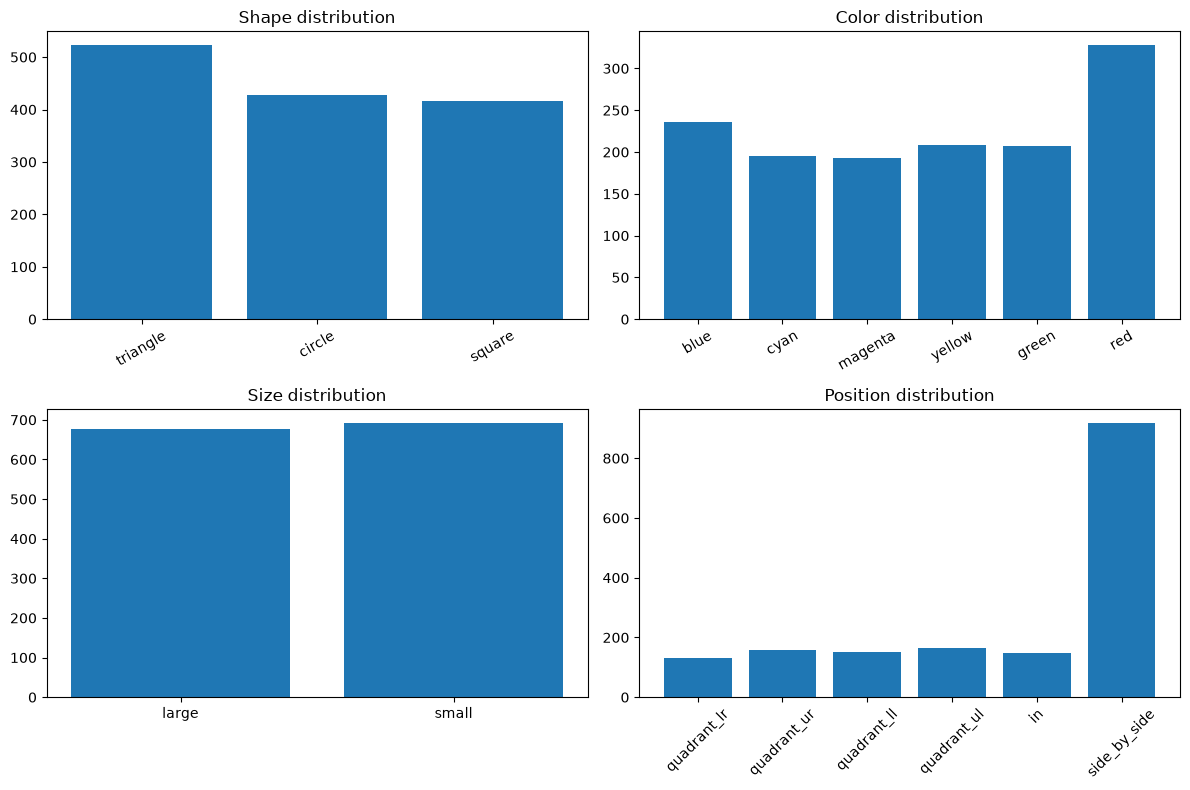

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].bar(shape_counter.keys(), shape_counter.values())
axes[0, 0].set_title("Shape distribution")
axes[0, 0].tick_params(axis="x", rotation=30)

axes[0, 1].bar(color_counter.keys(), color_counter.values())
axes[0, 1].set_title("Color distribution")
axes[0, 1].tick_params(axis="x", rotation=30)

axes[1, 0].bar(size_counter.keys(), size_counter.values())
axes[1, 0].set_title("Size distribution")

axes[1, 1].bar(position_counter.keys(), position_counter.values())
axes[1, 1].set_title("Position distribution")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 9. Numero di oggetti per immagine

In [16]:
def count_objects(symbol):
    return sum(len(objects) for objects in symbol.values())

df_train["num_objects"] = df_train["symbol_parsed"].apply(count_objects)

df_train["num_objects"].describe()


count    1000.000000
mean        1.668000
std         1.339989
min         1.000000
25%         1.000000
50%         1.000000
75%         1.250000
max         6.000000
Name: num_objects, dtype: float64

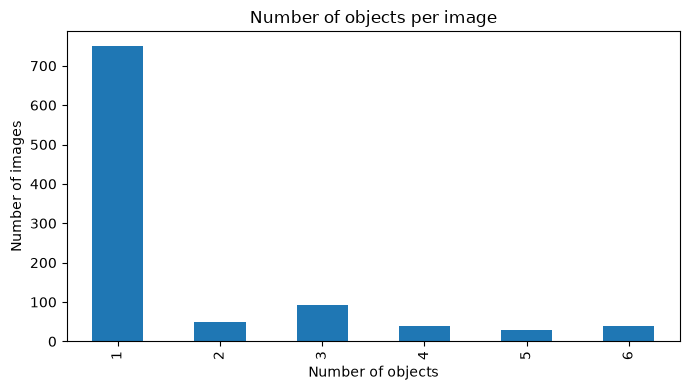

In [17]:
object_counts = df_train["num_objects"].value_counts().sort_index()

ax = object_counts.plot(
    kind="bar",
    figsize=(7, 4),
    title="Number of objects per image"
)
ax.set_xlabel("Number of objects")
ax.set_ylabel("Number of images")
plt.tight_layout()
plt.show()


## 10. Estrazione dei concetti interpretabili

In [18]:
def extract_concepts(symbol):
    objects = list(iter_objects(symbol))

    if not objects:
        return {
            "position": None,
            "shape": None,
            "color": None,
            "size": None,
            "num_objects": 0,
        }

    position, obj = objects[0]

    return {
        "position": position,
        "shape": obj.get("shape"),
        "color": obj.get("color"),
        "size": obj.get("size"),
        "num_objects": len(objects),
    }

concepts = df_train["symbol_parsed"].apply(extract_concepts)
concept_df = pd.DataFrame(concepts.tolist())

df_concepts = pd.concat(
    [
        df_train[["filename", "task_id", "label"]].reset_index(drop=True),
        concept_df.reset_index(drop=True),
    ],
    axis=1,
)

df_concepts.head(10)


,filename,task_id,label,position,shape,color,size,num_objects
0,0/0000.png,0,1,quadrant_lr,triangle,blue,large,1
1,0/0001.png,0,0,quadrant_lr,circle,cyan,small,1
2,0/0002.png,0,0,quadrant_ur,circle,blue,small,1
3,0/0003.png,0,1,quadrant_ll,triangle,magenta,small,1
4,0/0004.png,0,0,quadrant_ul,circle,blue,large,1
5,0/0005.png,0,0,in,circle,yellow,large,1
6,0/0006.png,0,0,quadrant_ll,circle,magenta,large,1
7,0/0007.png,0,1,quadrant_ll,triangle,yellow,large,1
8,0/0008.png,0,0,in,square,green,large,1
9,0/0009.png,0,0,quadrant_ul,square,cyan,large,1


Questi concetti forniscono le variabili interpretabili necessarie per confrontare in seguito il comportamento della CNN con la descrizione simbolica della scena.

A livello concettuale, confronteremo:

`immagine -> CNN -> predizione`

con:

`immagine -> concetti -> regola simbolica → etichetta`

Questo crea il collegamento tra CNN, SHAP, Concept Bottleneck Models.

## 11. Visualizzazione delle immagini

Image path: /home/cosimo/Downloads/kandy-xai/data/samples/sets/train/0/0000.png
Image size: (224, 224)
Task: 0
Label: 1
Symbol: {'quadrant_lr': [{'shape': 'triangle', 'color': 'blue', 'size': 'large'}]}


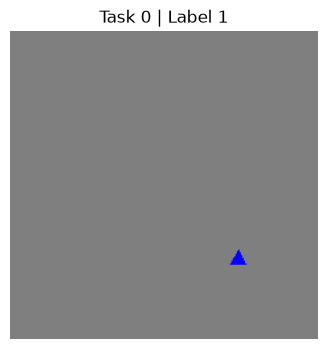

In [19]:
sample = df_train.iloc[0]

img_path = TRAIN_DIR / sample["filename"]
img = Image.open(img_path)

print("Image path:", img_path)
print("Image size:", img.size)
print("Task:", sample["task_id"])
print("Label:", sample["label"])
print("Symbol:", sample["symbol"])

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
plt.title(f"Task {sample.task_id} | Label {sample.label}")
plt.show()


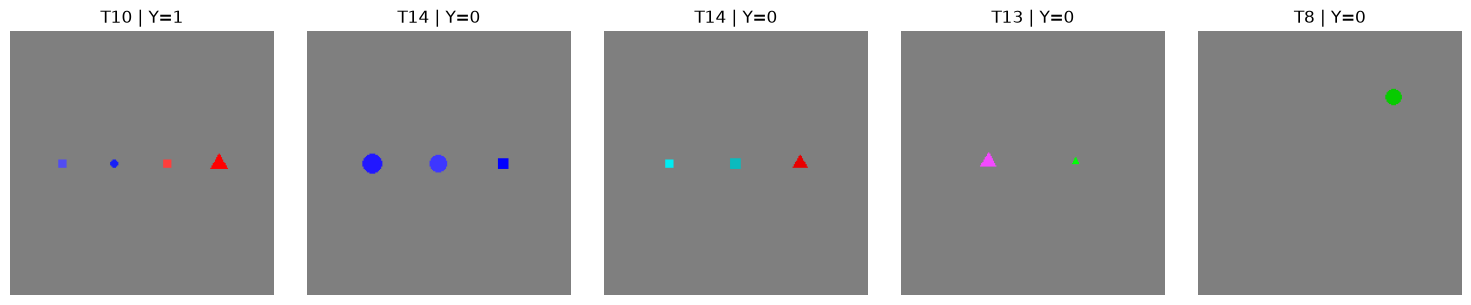

In [20]:
def show_samples(df, n=5, random_state=42):
    samples = df.sample(min(n, len(df)), random_state=random_state)

    fig, axes = plt.subplots(
        1, len(samples),
        figsize=(3 * len(samples), 3)
    )

    if len(samples) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = Image.open(TRAIN_DIR / row["filename"])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"T{row.task_id} | Y={row.label}")

    plt.tight_layout()
    plt.show()

show_samples(df_train, n=5)


### Esempi positivi e negativi con descrizione

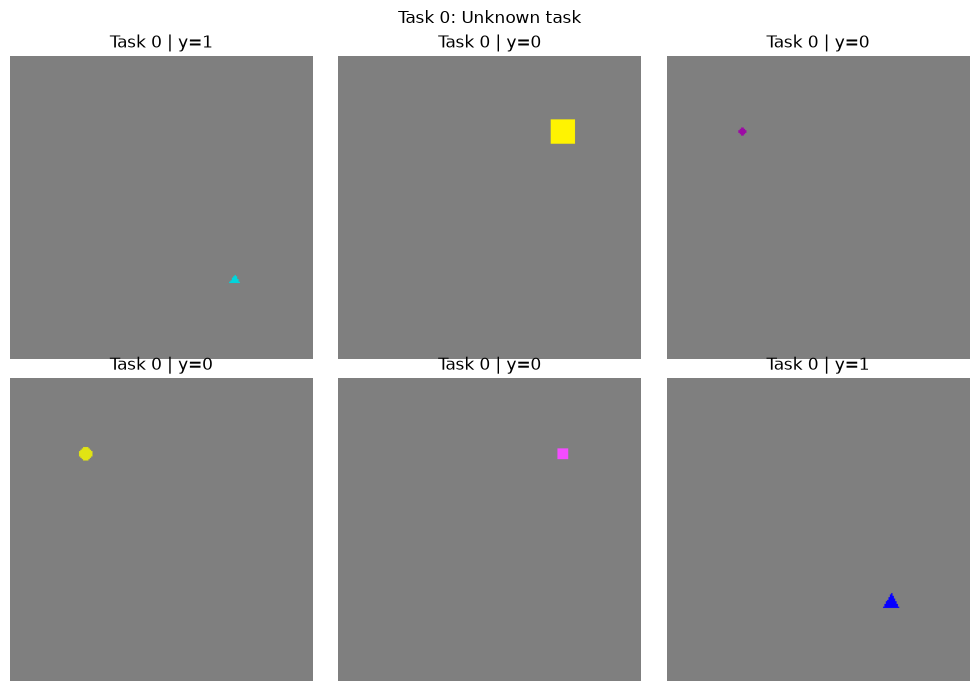

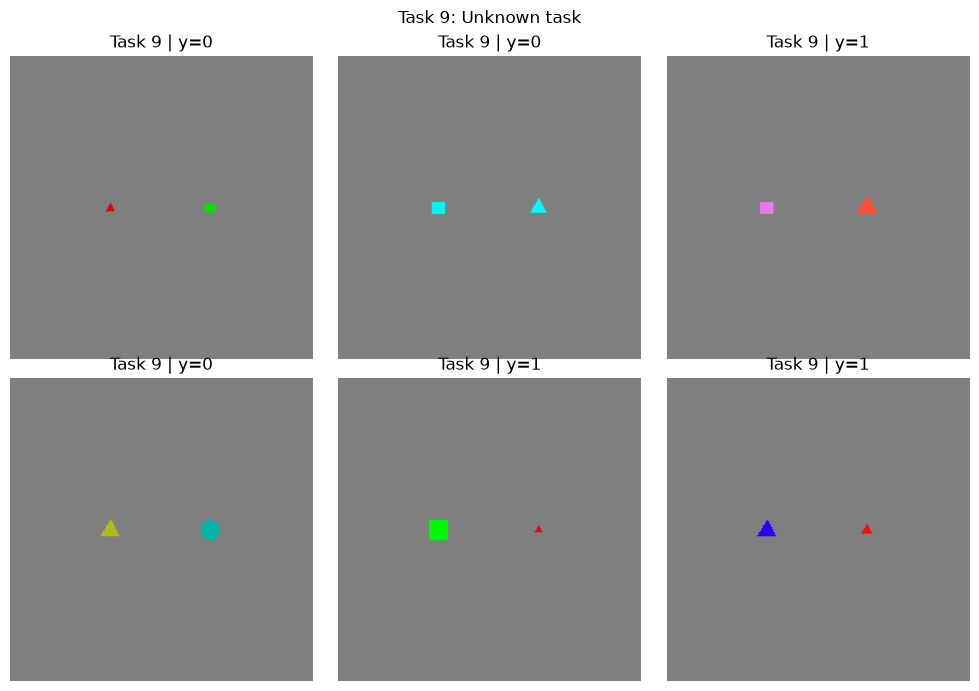

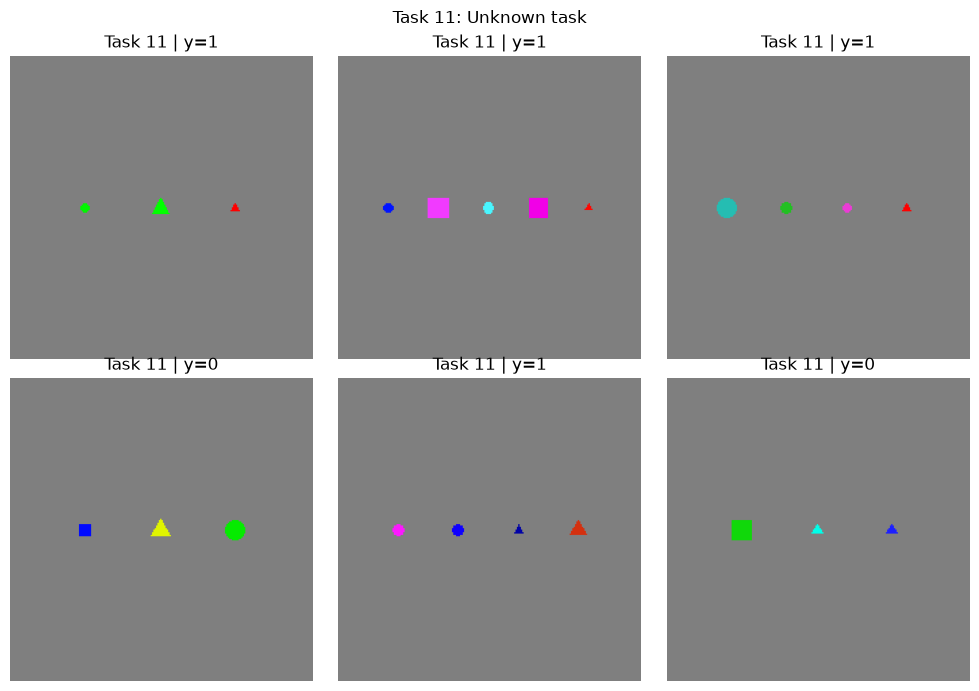

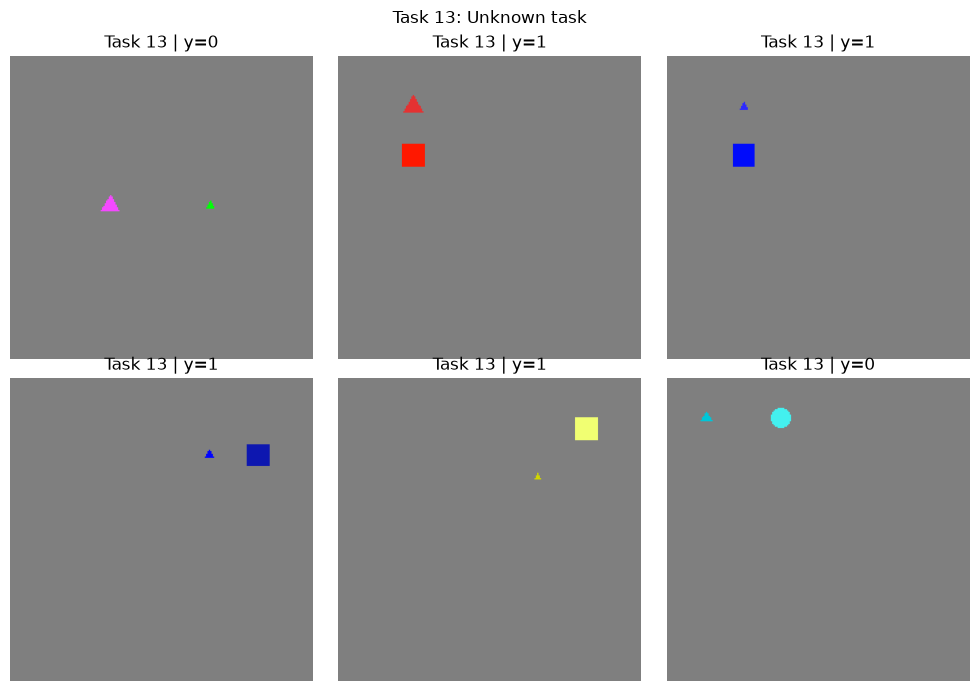

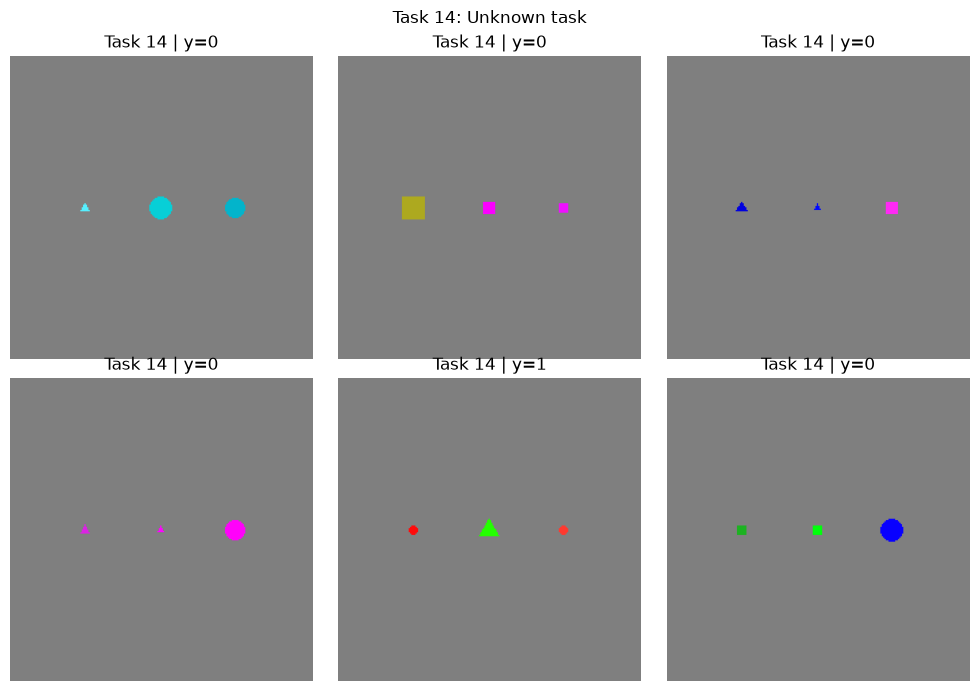

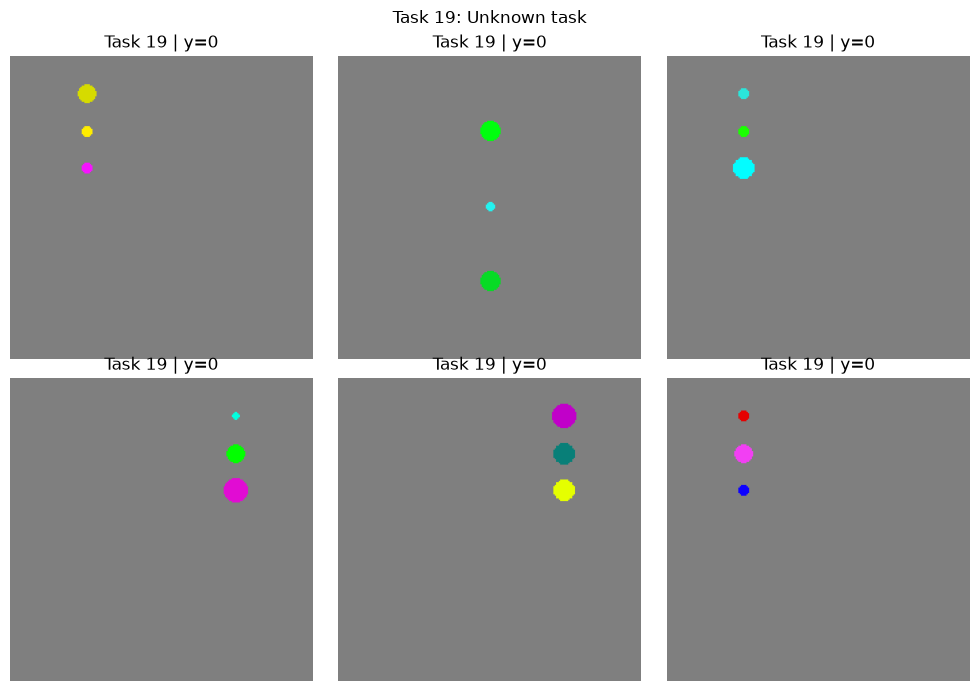

In [23]:
def show_task_examples(df, task_id, n=6, seed=123):
    subset = df[df["task_id"] == task_id]
    samples = subset.sample(n=min(n, len(subset)), random_state=seed)

    fig, axes = plt.subplots(2, 3, figsize=(10, 7))
    axes = axes.ravel()

    for ax in axes:
        ax.axis("off")

    for ax, (_, row) in zip(axes, samples.iterrows()):
        img = Image.open(TRAIN_DIR / row["filename"])
        ax.imshow(img)
        ax.axis("off")
        ax.set_title(f"Task {row.task_id} | y={row.label}")

    fig.suptitle(f"Task {task_id}: {df.get(task_id, 'Unknown task')}")
    plt.tight_layout()
    plt.show()

for task_id in [0, 9, 11, 13, 14, 19]:
    show_task_examples(df_train, task_id)

## 12. Panoramica delle task

In [ ]:
task_names = {
    0: "triangle vs any",
    1: "square vs any",
    2: "circle vs any",
    3: "red vs any",
    4: "green vs any",
    5: "blue vs any",
    6: "cyan vs any",
    7: "magenta vs any",
    8: "yellow vs any",
    9: "red triangle on the right",
    10: "red triangle on the right and arbitrary objects",
    11: "red triangle on the right and at least one circle and arbitrary objects",
    12: "red triangle on the right and at least one blue object and arbitrary objects",
    13: "triangle and square, same color",
    14: "palindrome aba",
    15: "house",
    16: "car",
    17: "tower",
    18: "wagon",
    19: "traffic light",
}

task_overview = task_labels.copy()
task_overview["task_name"] = task_overview.index.map(task_names)

task_overview[
    ["task_name", "total", "positives", "negatives", "positive_ratio"]
]


## 13. Conclusioni

Il dataset KANDY contiene:

- 1000 immagini di training;
- 20 task di classificazione binaria;
- 50 campioni di training per task;
- annotazioni simboliche che descrivono le scene;
- concetti interpretabili come forma, colore, dimensione e posizione;
- regole logiche differenti tra le task.

Il baseline globale ottenuto dalla classe maggioritaria è circa 59,4%.

Le annotazioni simboliche costituiscono un riferimento utile per i successivi esperimenti di Explainable AI.
